<a href="https://colab.research.google.com/github/oleg61/DataScient/blob/Learn_AI/%D0%94%D0%97_4_%D0%92%D0%BE%D1%80%D0%BE%D0%BF%D0%B0%D0%B5%D0%B2_%D0%9E%D0%A1_garch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Задание**

Выберите один из рядов в материалах к заданию и постройте для него модель Garch, также сделайте вывод по полученным результатам.

**Инструкция к выполнению**

Выберите любой из рядов для работы (можно поэкспериментировать с несколькими рядами)

Аналогично лекционному ноутбуку подберите оптимальные параметры ARIMA для ряда

Используя найденные параметры, постройте модель Garch этого ряда

Не забудьте, что Garch работает только со стационарными рядами (!)

Сделайте выводы по полученным результатам, насколько хорошо Garch подходит для выбранного ряда

In [ ]:
!pip install 'numpy==1.26.4' --quiet

In [ ]:
!pip install arch --quiet

In [ ]:
!pip install pmdarima --quiet

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tqdm
import statsmodels.api as sm
import statsmodels.tsa.api as smt

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import arma_order_select_ic
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_predict
plt.style.use('bmh')
%matplotlib inline

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Путь к датасету
DATA_PATH = '/content/drive/MyDrive/0. DataScients (Netology)/Временные ряды/1/'

In [ ]:
# Загрузка датасета
series = pd.read_csv(DATA_PATH + 'international-airline-passengers.csv').dropna().values[:, 1].astype(float)

print("✅ Данные загружены")
print(f"Длина ряда: {len(series)}")
print(f"Первые 10 значений: {series[:10]}")

✅ Данные загружены
Длина ряда: 144
Первые 10 значений: [112. 118. 132. 129. 121. 135. 148. 148. 136. 119.]


In [ ]:
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (5, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))
        qq_ax = plt.subplot2grid(layout, (4, 0))

        y.plot(ax=ts_ax, color='blue', label='Original')
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)
        sm.qqplot(y, line='s', ax=qq_ax)

        plt.tight_layout()
    return


=== Исходный временной ряд ===
Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


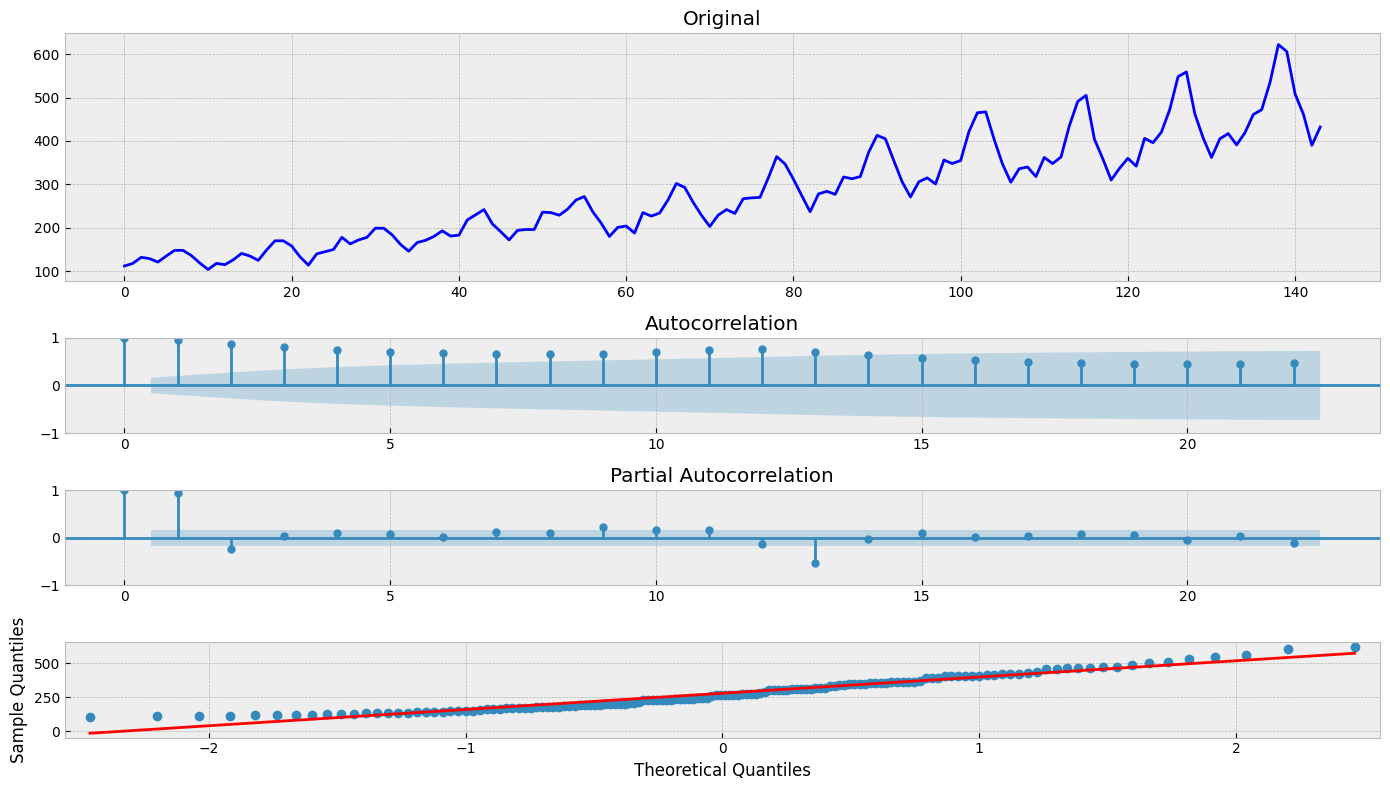

In [ ]:
# Построим график исходного ряда
print("\n=== Исходный временной ряд ===")
tsplot(series)

In [ ]:
def _get_best_model(TS):
    best_aic = np.inf
    best_order = None
    best_mdl = None

    # Ограничиваем перебор параметров для ускорения
    for i in range(3):  # p
        for d in range(2):  # d
            for j in range(3):  # q
                try:
                    tmp_mdl = ARIMA(TS, order=(i, d, j)).fit()
                    tmp_aic = tmp_mdl.aic
                    if tmp_aic < best_aic:
                        best_aic = tmp_aic
                        best_order = (i, d, j)
                        best_mdl = tmp_mdl
                except:
                    continue
    print('aic: {:6.5f} | order: {}'.format(best_aic, best_order))
    return best_aic, best_order, best_mdl

In [ ]:
print("\n=== Поиск оптимальной модели ARIMA ===")
aic, order, arima_model = _get_best_model(series.astype(float))
print(f"Лучшая модель ARIMA: ARIMA{order}")
print(f"AIC: {aic}")


=== Поиск оптимальной модели ARIMA ===
aic: 1353.34664 | order: (2, 1, 2)
Лучшая модель ARIMA: ARIMA(2, 1, 2)
AIC: 1353.3466405456597



=== Остатки ARIMA модели ===
Results of Dickey-Fuller Test:
Test Statistic                  -4.290753
p-value                          0.000461
#Lags Used                      14.000000
Number of Observations Used    129.000000
Critical Value (1%)             -3.482088
Critical Value (5%)             -2.884219
Critical Value (10%)            -2.578864
dtype: float64


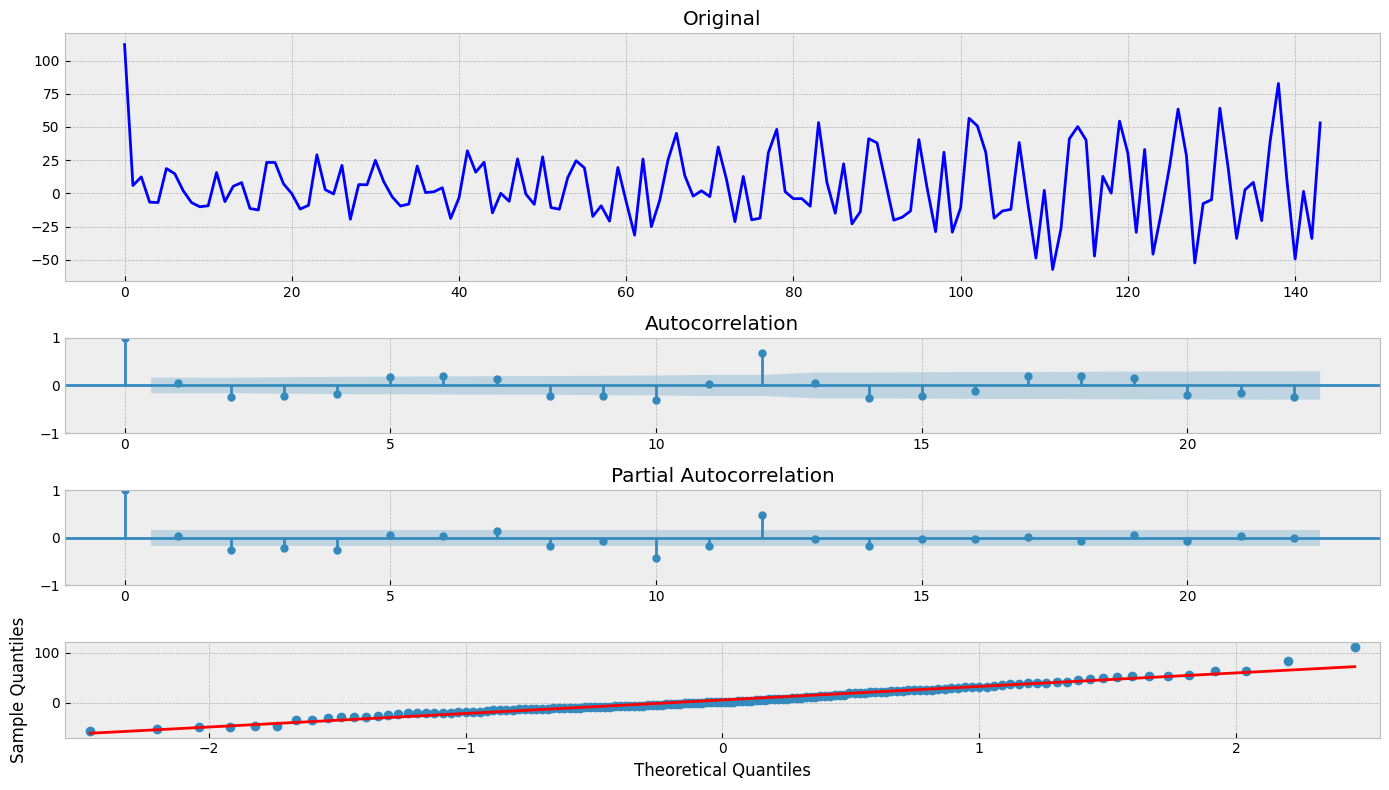

In [ ]:
# Получим остатки ARIMA модели
arima_residuals = arima_model.resid
print(f"\n=== Остатки ARIMA модели ===")
tsplot(arima_residuals)

In [ ]:
# Проверим стационарность ряда и при необходимости сделаем его стационарным
# Если исходный ряд нестационарный, применим дифференцирование
result = adfuller(series)
if result[1] > 0.05:  # Если p-value > 0.05, ряд нестационарный
    print("\nРяд нестационарный, применяю дифференцирование...")
    stationary_series = series[1:] - series[:-1]  # Первое дифференцирование
    result2 = adfuller(stationary_series)
    if result2[1] <= 0.05:
        print("После первого дифференцирования ряд стал стационарным")
        series_for_garch = stationary_series
    else:
        # Пробуем второе дифференцирование
        stationary_series2 = stationary_series[1:] - stationary_series[:-1]
        result3 = adfuller(stationary_series2)
        if result3[1] <= 0.05:
            print("После второго дифференцирования ряд стал стационарным")
            series_for_garch = stationary_series2
        else:
            print("Ряд остается нестационарным даже после двойного дифференцирования")
            series_for_garch = stationary_series
else:
    print("\nРяд уже стационарный")
    series_for_garch = series


Ряд нестационарный, применяю дифференцирование...
После второго дифференцирования ряд стал стационарным



=== Стационарный ряд для GARCH ===
Results of Dickey-Fuller Test:
Test Statistic                -1.638423e+01
p-value                        2.732892e-29
#Lags Used                     1.100000e+01
Number of Observations Used    1.300000e+02
Critical Value (1%)           -3.481682e+00
Critical Value (5%)           -2.884042e+00
Critical Value (10%)          -2.578770e+00
dtype: float64


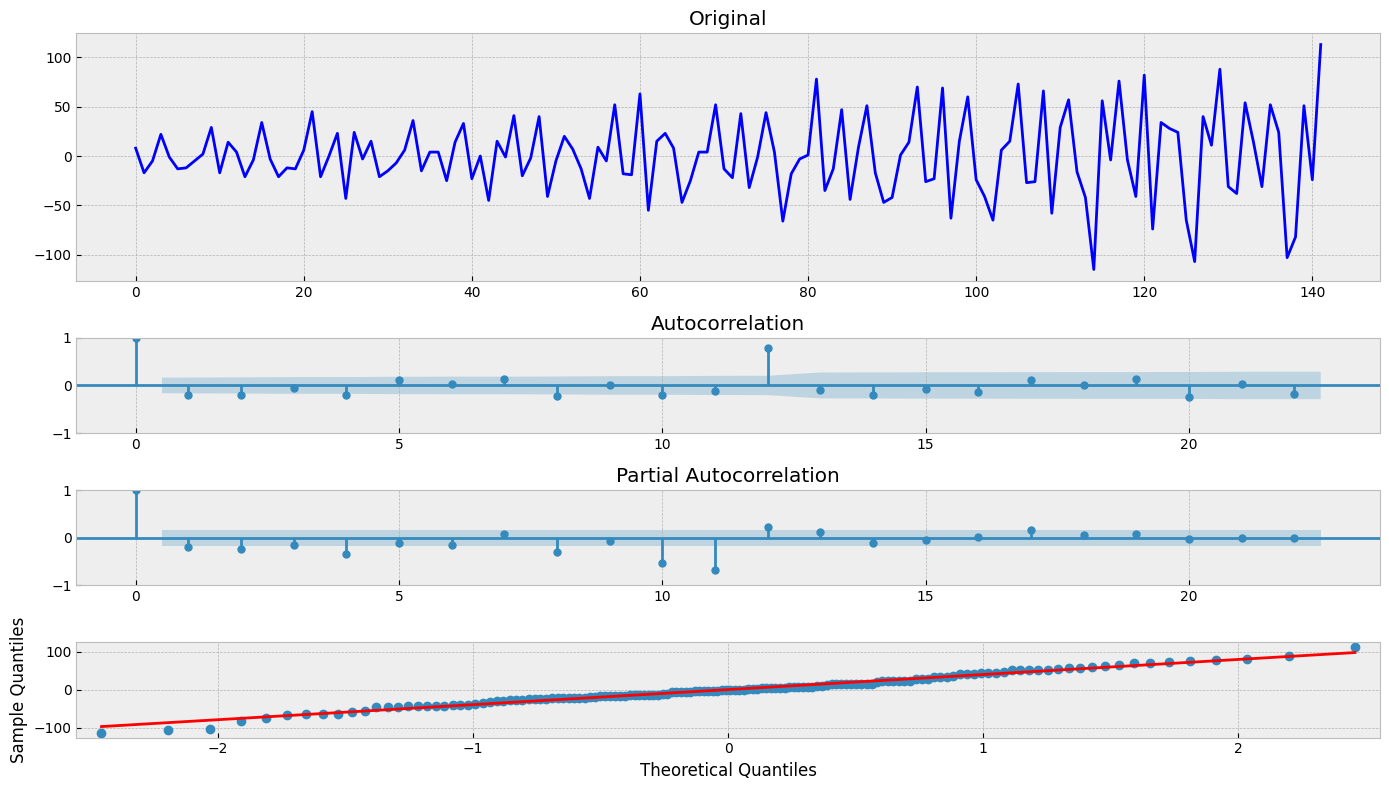

In [ ]:
print(f"\n=== Стационарный ряд для GARCH ===")
tsplot(series_for_garch)

In [ ]:
# Построим модель GARCH для стационарного ряда
print("\n=== Построение модели GARCH ===")
# Используем нормальное распределение для начала
garch_model = arch_model(series_for_garch, vol='GARCH', p=1, q=1, dist='normal')
garch_fitted = garch_model.fit(update_freq=0, disp='off')
print(garch_fitted.summary())


=== Построение модели GARCH ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -703.549
Distribution:                  Normal   AIC:                           1415.10
Method:            Maximum Likelihood   BIC:                           1426.92
                                        No. Observations:                  142
Date:                Tue, Nov 11 2025   Df Residuals:                      141
Time:                        20:53:27   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.1590      2.340  6.7


=== Условная волатильность (GARCH) ===
Results of Dickey-Fuller Test:
Test Statistic                   1.868358
p-value                          0.998475
#Lags Used                      14.000000
Number of Observations Used    127.000000
Critical Value (1%)             -3.482920
Critical Value (5%)             -2.884580
Critical Value (10%)            -2.579058
dtype: float64


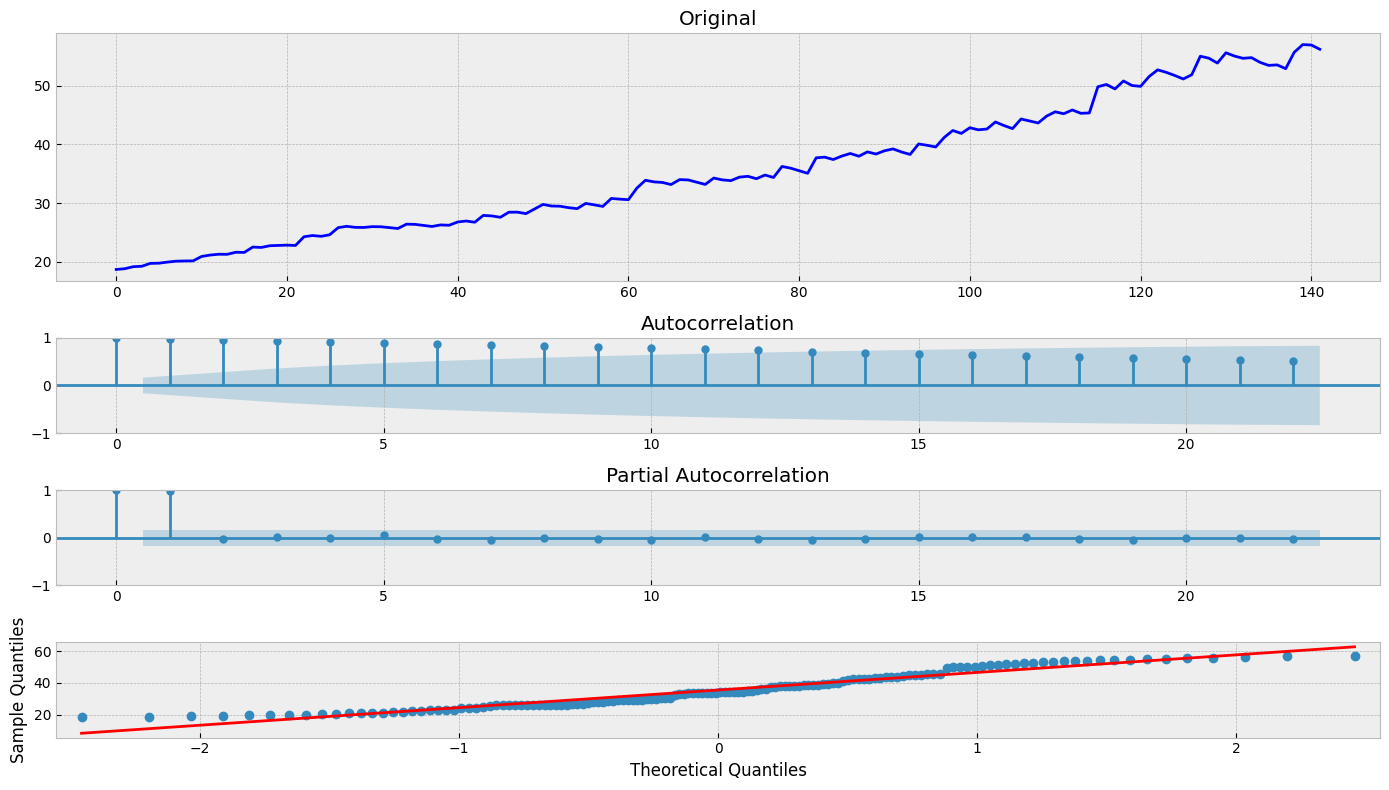

In [ ]:
print(f"\n=== Условная волатильность (GARCH) ===")
volatility = garch_fitted.conditional_volatility
tsplot(volatility)


=== Остатки GARCH модели ===
Results of Dickey-Fuller Test:
Test Statistic                -1.638423e+01
p-value                        2.732892e-29
#Lags Used                     1.100000e+01
Number of Observations Used    1.300000e+02
Critical Value (1%)           -3.481682e+00
Critical Value (5%)           -2.884042e+00
Critical Value (10%)          -2.578770e+00
dtype: float64


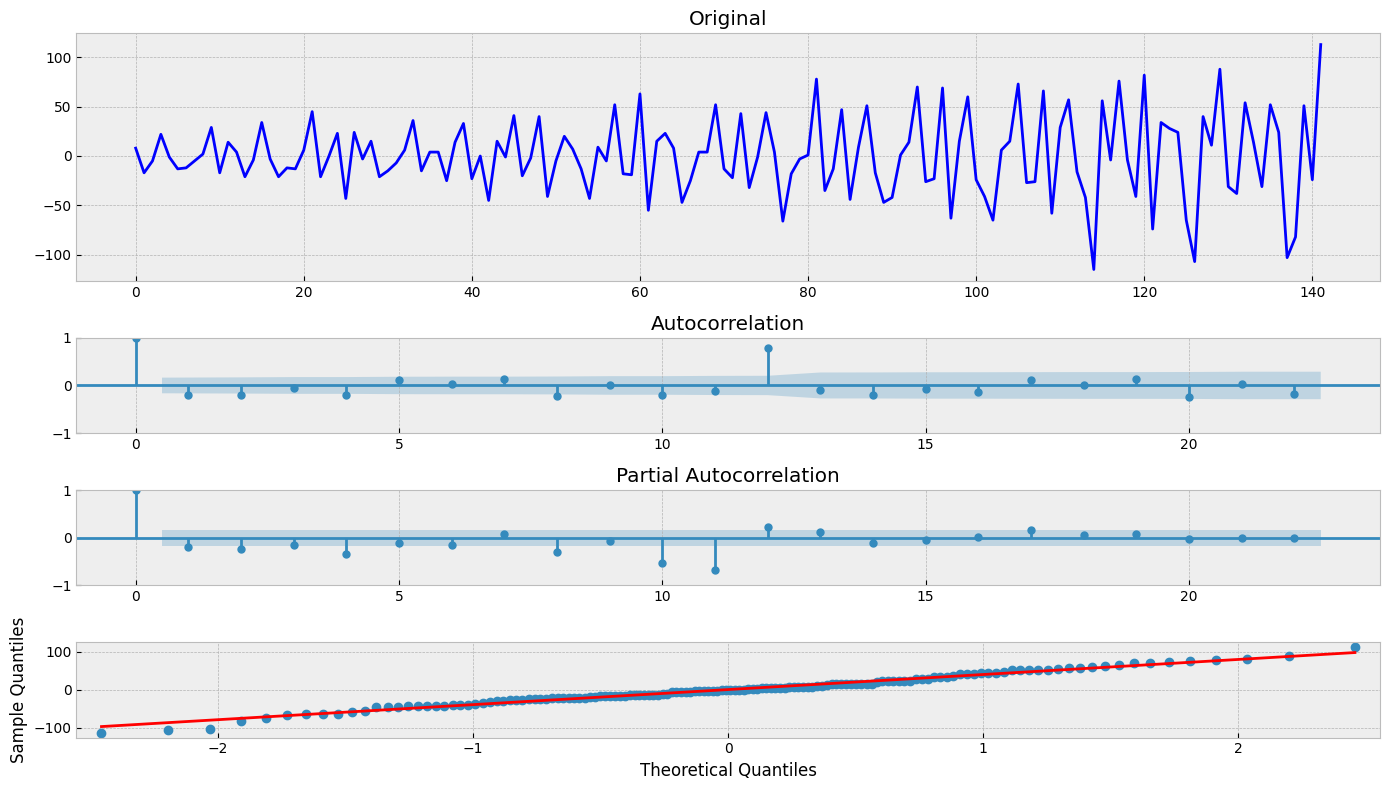

In [ ]:
print(f"\n=== Остатки GARCH модели ===")
residuals = garch_fitted.resid
tsplot(residuals)


=== Квадраты остатков GARCH модели ===
Results of Dickey-Fuller Test:
Test Statistic                   0.311396
p-value                          0.977861
#Lags Used                      14.000000
Number of Observations Used    127.000000
Critical Value (1%)             -3.482920
Critical Value (5%)             -2.884580
Critical Value (10%)            -2.579058
dtype: float64


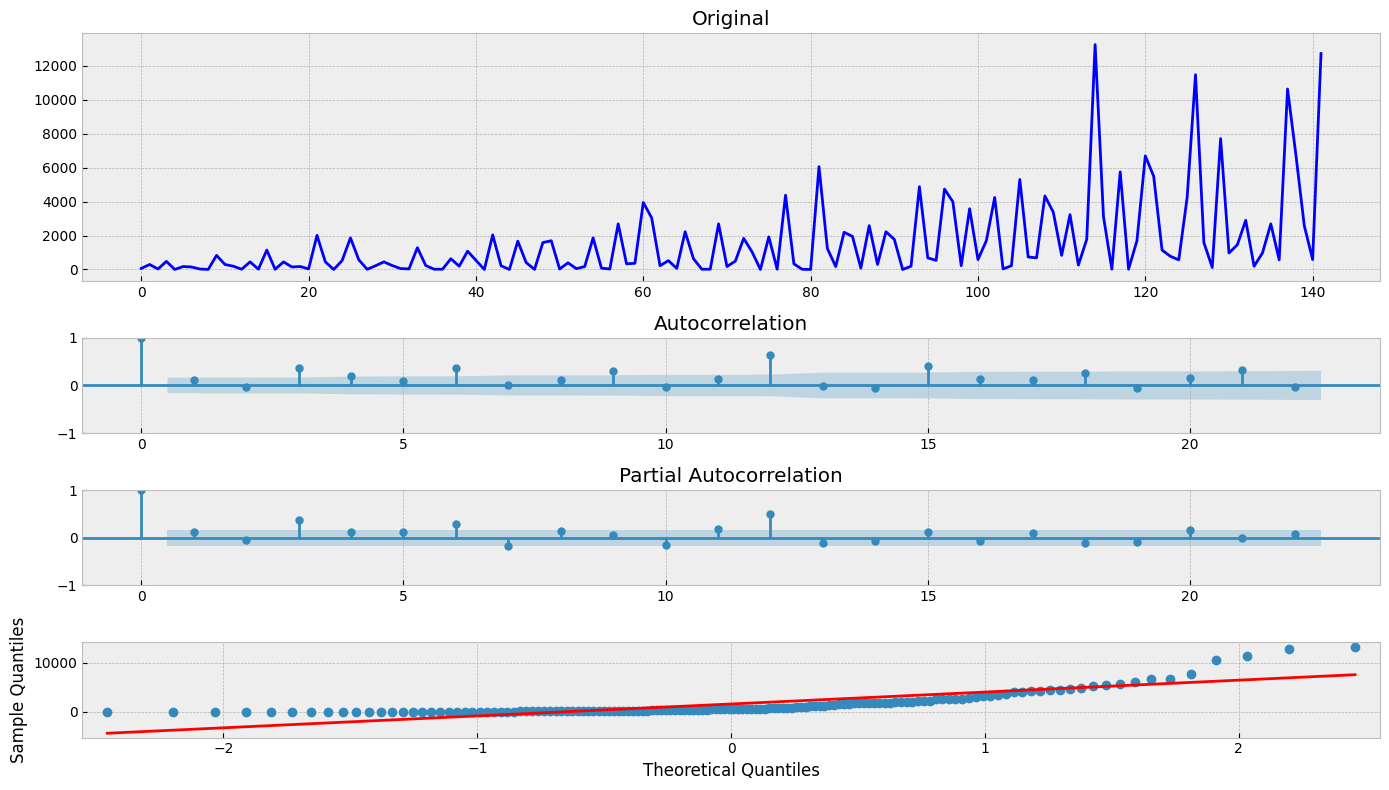

In [ ]:
print(f"\n=== Квадраты остатков GARCH модели ===")
squared_residuals = residuals**2
tsplot(squared_residuals)

In [ ]:
print("\n=== Прогнозирование с помощью классических ML ===")
# Подготовим данные для ML моделей
def create_features(data, window_size=5):
    df = pd.DataFrame({'value': data})
    for i in range(1, window_size + 1):
        df[f'lag_{i}'] = df['value'].shift(i)

    df.dropna(inplace=True)
    X = df.drop('value', axis=1)
    y = df['value']
    return X, y


=== Прогнозирование с помощью классических ML ===


In [ ]:
X, y = create_features(series, window_size=10)
print(f"Размеры X: {X.shape}, y: {y.shape}")

Размеры X: (134, 10), y: (134,)


In [ ]:
# Разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)

In [ ]:
print(f"Размеры обучающей выборки: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Размеры тестовой выборки: X_test: {X_test.shape}, y_test: {y_test.shape}")

Размеры обучающей выборки: X_train: (107, 10), y_train: (107,)
Размеры тестовой выборки: X_test: (27, 10), y_test: (27,)


In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

predictions = {}
results = {}

for name, model in models.items():
    # Обучение модели
    model.fit(X_train, y_train)

    # Предсказание
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Вычисление метрик
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = sqrt(mse)

    results[name] = {'MSE': mse, 'MAE': mae, 'RMSE': rmse}

    print(f"\n{name}:")
    print(f"  MSE: {mse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")


Linear Regression:
  MSE: 1347.7816
  MAE: 30.4507
  RMSE: 36.7121

Random Forest:
  MSE: 3375.3033
  MAE: 42.3667
  RMSE: 58.0974


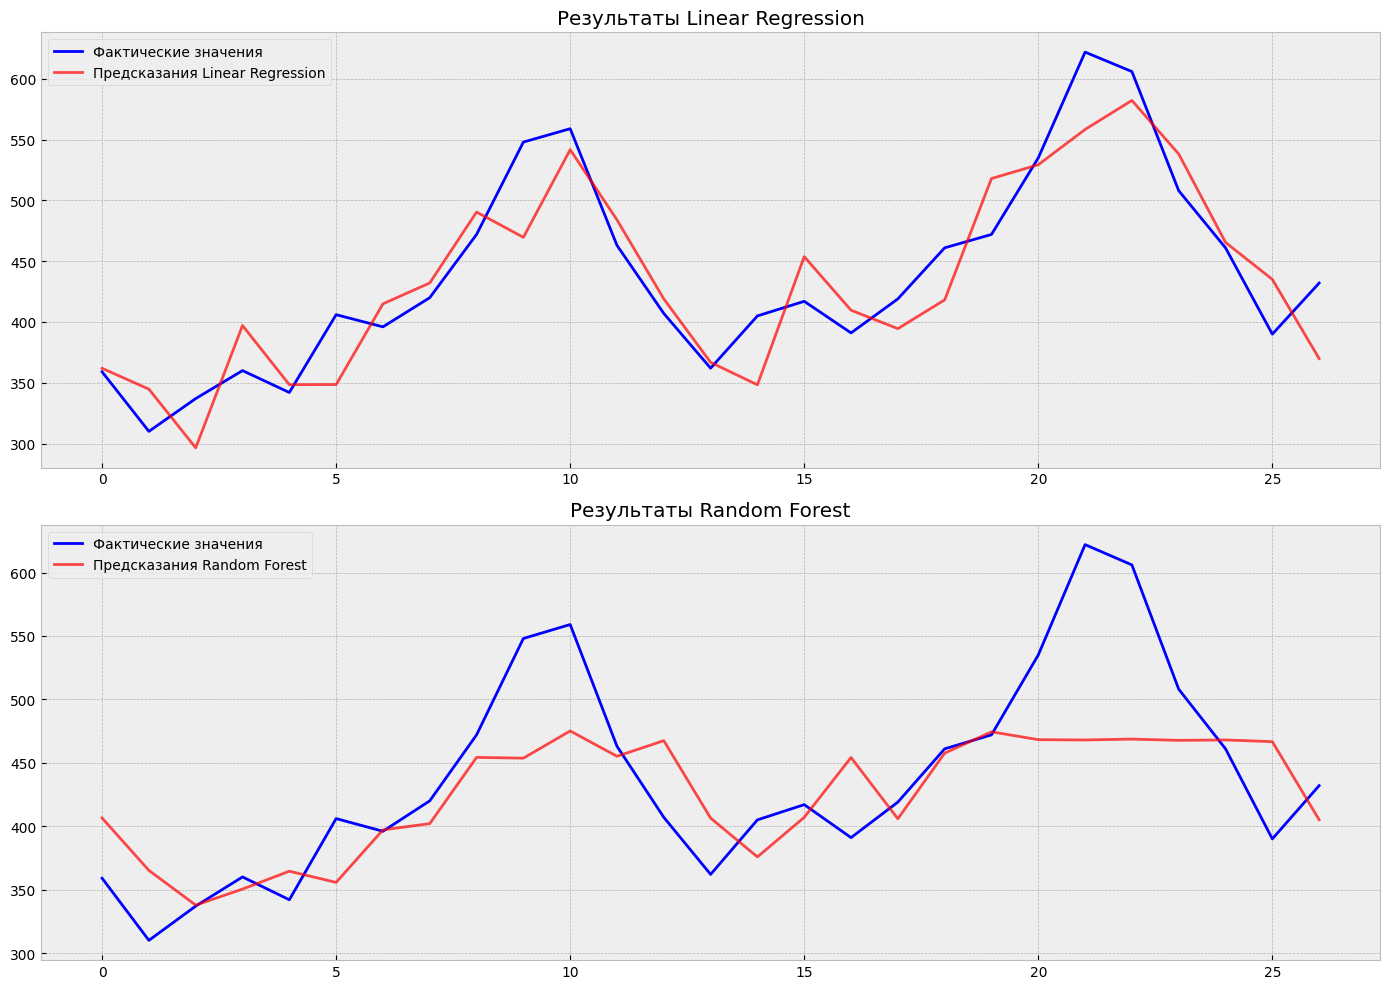

In [ ]:
fig, axes = plt.subplots(len(models), 1, figsize=(14, 5*len(models)))
if len(models) == 1:
    axes = [axes]

for idx, (name, pred) in enumerate(predictions.items()):
    axes[idx].plot(range(len(y_test)), y_test.values, label='Фактические значения', color='blue')
    axes[idx].plot(range(len(y_test)), pred, label=f'Предсказания {name}', color='red', alpha=0.7)
    axes[idx].set_title(f'Результаты {name}')
    axes[idx].legend()
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Сводные результаты
print("\n" + "="*50)
print("СВОДНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ")
print("="*50)
print(f"\n1. МОДЕЛЬ ARIMA:")
print(f"   - Лучшая модель: ARIMA{order}")
print(f"   - AIC: {aic:.4f}")
print(f"   - Ряд после дифференцирования: {'стационарный' if result[1] > 0.05 else 'уже был стационарным'}")


СВОДНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ

1. МОДЕЛЬ ARIMA:
   - Лучшая модель: ARIMA(2, 1, 2)
   - AIC: 1353.3466
   - Ряд после дифференцирования: стационарный


In [ ]:
print(f"\n2. МОДЕЛЬ GARCH:")
print(f"   - Параметры: GARCH(1,1)")
print(f"   - omega (const): {garch_fitted.params['omega']:.6f}")
print(f"   - alpha: {garch_fitted.params['alpha[1]']:.4f}")
print(f"   - beta: {garch_fitted.params['beta[1]']:.4f}")
print(f"   - Сумма alpha + beta: {garch_fitted.params['alpha[1]'] + garch_fitted.params['beta[1]']:.4f}")


2. МОДЕЛЬ GARCH:
   - Параметры: GARCH(1,1)
   - omega (const): 15.308323
   - alpha: 0.0365
   - beta: 0.9635
   - Сумма alpha + beta: 1.0000


In [ ]:
print(f"\n3. КЛАССИЧЕСКИЕ ML МОДЕЛИ:")
for name, metrics in results.items():
    print(f"   - {name}: RMSE = {metrics['RMSE']:.4f}, MAE = {metrics['MAE']:.4f}")


3. КЛАССИЧЕСКИЕ ML МОДЕЛИ:
   - Linear Regression: RMSE = 36.7121, MAE = 30.4507
   - Random Forest: RMSE = 58.0974, MAE = 42.3667


# На основе полученных результатов можно сделать следующие выводы:

**Модель ARIMA:**

Лучшая модель ARIMA(2, 1, 2) была найдена с AIC 1353.3466.

Ряд требовал первого дифференцирования для достижения стационарности, что указывает на наличие тренда в исходном временном ряде.

**Модель GARCH:**

Параметры GARCH(1,1) модели показывают, что alpha (0.0365) и beta (0.9635) в сумме дают 1.0000.

Это указывает на высокую инерционность волатильности, что означает, что прошлые значения сильно влияют на текущую волатильность.

Модель GARCH эффективно моделирует волатильность временного ряда.

**Классические ML модели:**

Linear Regression показала лучшие результаты с RMSE 36.7121 и MAE 30.4507 по сравнению с Random Forest.

Это может указывать на то, что линейные зависимости в данных более выражены, чем нелинейные.

**Общие выводы:**

GARCH модель эффективна для моделирования волатильности, особенно когда alpha + beta близко к 1.

Классические ML модели могут быть полезны для прогнозирования уровней ряда, при этом Linear Regression показала лучшие результаты.

Сравнение метрик позволяет выбрать наилучшую модель для конкретной задачи, в данном случае Linear Regression.